<h1>ReAct: Build Reasoning and Acting AI Agents with LangGraph</h1>

You're a software engineer on a mission: build an AI agent that doesn't just respond—it thinks. In this lab, you'll step into the role of an AI architect, designing a smart assistant that solves tough problems by reasoning through them and taking purposeful actions.

Using the ReAct (Reasoning + Acting) framework, you'll teach your agent to think step by step, consult tools like search engines or calculators, and adapt on the fly. It’s not just about answers—it’s about how the agent gets there.

By the end of the lab, your AI will <u>face a mystery that can’t be solved with knowledge alone. It will need logic, resourcefulness, and the ability to act—just like you</u>, the engineer who built it.


<h2>What is ReAct?</h2>

ReAct stands for Reasoning + Acting. It's a framework that combines:

- Reasoning: The agent thinks through problems step by step, maintaining an internal dialogue about what it needs to do.
- Acting: The agent can use external tools (search engines, calculators, APIs) to gather information or perform actions.
- Observing: The agent processes the results from its actions and incorporates them into its reasoning.

This creates a powerful loop: Think → Act → Observe → Think → Act → ...


<h2>Why ReAct Matters</h2>
Traditional language models are limited by their training data cutoff and can't access real-time information. ReAct agents overcome tradition LLM limitation by:

- Accessing current information through web searches
- Performing calculations with specialized tools
- Breaking down complex problems into manageable steps
- Adapting their approach based on intermediate results


<h2>Objectives</h2>
After completing this lab you will be able to:

- Use the ReAct framework to solve multi-step problems with external tools
- Teach an AI agent to reason step by step, take actions, and adapt based on results
- Build a smart assistant that can handle tasks requiring logic and tool use


<h2>Setup & Installation</h2>
For this lab, we will be using the following libraries:

- LangGraph: A framework for building stateful, multi-step AI applications using graphs.
- LangChain: A toolkit that provides tools and abstractions for working with language models.
- LangChain-Ollama: Ollama integration for LangChain.
- LangChain-Community: Community-contributed tools and integrations.

<p>
Use Python 3.12.10

In [12]:
%%capture
%pip install langgraph==0.3.34 
%pip install langchain-openai==0.3.14 
%pip install langchainhub==0.1.21 
%pip install langchain==0.3.24 
%pip install pygraphviz==1.14 
%pip install langchain-community==0.3.23
%pip install langchain-ollama==0.3.10

In [13]:
import os
import json
import getpass
from typing import List, Dict
from langchain_community.utilities.tavily_search import TavilySearchAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import END, StateGraph, MessagesState

In [4]:
# copy your Tavily API key in the pop up shown when executing this cell

def _set_if_undefined(var: str) -> None:
    if os.environ.get(var):
      return
    os.environ[var] = getpass.getpass(var)
_set_if_undefined("TAVILY_API_KEY")

In [14]:
import warnings 
warnings.filterwarnings('ignore')

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.tools import tool
import os
import json


# Initialize the Tavily search tool
search = TavilySearchResults()

@tool
def search_tool(query: str):
    """
    Search the web for information using Tavily API.

    :param query: The search query string
    :return: Search results related to the query
    """
    return search.invoke(query)

In [6]:
search_tool.invoke("What's the weather like in Tokyo today?")

[{'title': 'Japan Weather in October 2026: Foliage & What to Wear',
  'url': 'https://www.umetravel.com/japan-weather/weather-in-october.html',
  'content': "Hokkaido has the earliest autumn foliage in Japan\n\nHokkaido has the earliest autumn foliage in Japan\n\n### Central Japan: Warm Days, Cool Nights—Perfect for Sightseeing\n\nTokyo· Yokohama· Kyoto· Osaka· Nara· Nagoya\n\nWeather features: Comfortable warmth during the day, cooler evenings, low rainfall\n\n|  |  |  |  |\n ---  --- |\n| City | Avg. High | Avg. Low | Rain Chance |\n| Tokyo | 22°C (72°F) | 15°C (59°F) | 27% – 32% |\n| Osaka | 23°C (73°F) | 15°C (59°F) | 25% – 31% |\n| Kyoto | 22°C (72°F) | 13°C (55°F) | 28% – 34% |\n| Nagoya | 23°C (73°F) | 14°C (57°F) | 26% – 33% |\n\nComfortable climate: Central Japan enjoys some of the most pleasant weather in October. Days remain mild to warm, especially early in the month, while evenings turn cool and refreshing. [...] UME Travel logo\nUME Travel Mobile logo\n\n# Japan Weather i

In [7]:
@tool
def recommend_clothing(weather: str) -> str:
    """
    Returns a clothing recommendation based on the provided weather description.

    This function examines the input string for specific keywords or temperature indicators 
    (e.g., "snow", "freezing", "rain", "85°F") to suggest appropriate attire. It handles 
    common weather conditions like snow, rain, heat, and cold by providing simple and practical 
    clothing advice.

    :param weather: A brief description of the weather (e.g., "Overcast, 64.9°F")
    :return: A string with clothing recommendations suitable for the weather
    """
    weather = weather.lower()
    if "snow" in weather or "freezing" in weather:
        return "Wear a heavy coat, gloves, and boots."
    elif "rain" in weather or "wet" in weather:
        return "Bring a raincoat and waterproof shoes."
    elif "hot" in weather or "85" in weather:
        return "T-shirt, shorts, and sunscreen recommended."
    elif "cold" in weather or "50" in weather:
        return "Wear a warm jacket or sweater."
    else:
        return "A light jacket should be fine."

In [8]:
tools=[search_tool,recommend_clothing]

tools_by_name={ tool.name:tool for tool in tools}

In [15]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("gemma4", model_provider="ollama")

In [16]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage,SystemMessage

chat_prompt = ChatPromptTemplate.from_messages([
    ("system", """
You are a helpful AI assistant that thinks step-by-step and uses tools when needed.

When responding to queries:
1. First, think about what information you need
2. Use available tools if you need current data or specific capabilities  
3. Provide clear, helpful responses based on your reasoning and any tool results

Always explain your thinking process to help users understand your approach.
"""),
    MessagesPlaceholder(variable_name="scratch_pad")
])

In [17]:
llm_with_tools = llm.bind_tools(tools)
model_react=chat_prompt| llm_with_tools

In [18]:
from typing import (Annotated,Sequence,TypedDict)
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# In ReAct, state management is crucial, as the agent must maintain context across multiple reasoning and acting steps.
class AgentState(TypedDict):
    """The state of the agent."""

    # add_messages is a reducer
    # See https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [19]:
# Example conversation flow:
state: AgentState = {"messages": []}

# append a message using the reducer properly
state["messages"] = add_messages(state["messages"], [HumanMessage(content="Hi")])
print("After greeting:", state["messages"])

# add another message (e.g. a question)
state["messages"] = add_messages(state["messages"], [HumanMessage(content="Weather in NYC?")])
print("After question:", state)

After greeting: [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='51e6d2fe-28db-4e53-96f5-a39542806350')]
After question: {'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='51e6d2fe-28db-4e53-96f5-a39542806350'), HumanMessage(content='Weather in NYC?', additional_kwargs={}, response_metadata={}, id='b6133eaa-9b39-4490-9a98-a0800c1e7439')]}


In [22]:
# Manual ReAct Execution (Understanding the Flow)


#Step1 : query processing

dummy_state: AgentState = {
    "messages": [HumanMessage( "What's the weather like in Zurich, and what should I wear based on the temperature?")]}

response = model_react.invoke({"scratch_pad":dummy_state["messages"]})

dummy_state["messages"]=add_messages(dummy_state["messages"],[response])

# step2 : tool execution
tool_call = response.tool_calls[-1]
print("Tool call:", tool_call)

tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
print("Tool result preview:", tool_result[0]['title'])

tool_message = ToolMessage(
    content=json.dumps(tool_result),
    name=tool_call["name"],
    tool_call_id=tool_call["id"]
)
dummy_state["messages"] = add_messages(dummy_state["messages"], [tool_message])

# Step 3: Processing Results and Next Action

response = model_react.invoke({"scratch_pad": dummy_state["messages"]})
dummy_state['messages'] = add_messages(dummy_state['messages'], [response])

# check if the model wants to use another tool
if response.tool_calls:
    tool_call = response.tool_calls[0]
    tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
    tool_message = ToolMessage(
        content=json.dumps(tool_result),
        name=tool_call["name"],
        tool_call_id=tool_call["id"]
    )
dummy_state['messages'] = add_messages(dummy_state['messages'], [tool_message])

# Step 4: Final Response Generation
response = model_react.invoke({"scratch_pad": dummy_state["messages"]})
print("Final response generated:", response.content is not None)
print("More tools needed:", bool(response.tool_calls))


# What Happens Here: 1. The model has all necessary information. 2. It synthesizes weather data and clothing recommendations.
# 3. It generates a comprehensive response to the user. 4. No more tool calls needed—the reasoning cycle is complete.


Tool call: {'name': 'search_tool', 'args': {'query': 'weather in Zurich'}, 'id': '5d513782-e9a7-42f0-82b6-f0215d32ef28', 'type': 'tool_call'}
Tool result preview: Zurich Weather Conditions: Temperature | 30 Days Forecast
Final response generated: True
More tools needed: False


<h2>Automating ReAct with Graphs</h2>

<h3>Why Use Graphs?</h3>
Manual ReAct execution is educational but impractical for real applications. LangGraph automates this process with a state machine that handles the reasoning loop automatically.

<h3>Building the Core Functions</h3>
<h4>Tool Execution Node</h4>

**Function Purpose:**
- Automatically execute all tool calls from the model
- Handle multiple simultaneous tool calls
- Return properly formatted tool messages


In [23]:
def tool_node(state: AgentState):
    """Execute all tool calls from the last message in the state."""
    outputs = []
    for tool_call in state["messages"][-1].tool_calls:
        tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content=json.dumps(tool_result),
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )
    return {"messages": outputs}

<h3>Model Invocation Node</h3>

<h4>Function Purpose:</h4>

- Call the ReAct-enabled model
- Pass the full conversation context
- Return the model's response (which may include tool calls)

In [24]:
def call_model(state: AgentState):
    """Invoke the model with the current conversation state."""
    response = model_react.invoke({"scratch_pad": state["messages"]})
    return {"messages": [response]}

<h3>Decision Logic</h3>

<h4>Function Purpose:</h4>

- Implement the control flow logic
- Decide whether the agent needs to use more tools
- Route the conversation to either tool execution or completion

In [25]:
def should_continue(state: AgentState):
    """Determine whether to continue with tool use or end the conversation."""
    messages = state["messages"]
    last_message = messages[-1]
    # If there is no function call, then we finish
    if not last_message.tool_calls:
        return "end"
    # Otherwise if there is, we continue
    else:
        return "continue"

<h3>Constructing the State Graph</h3>

<h4>Graph Structure Explained:</h4>

- Agent Node: Where reasoning happens and tool calls are generated.
- Tools Node: Where tool execution occurs.
- Conditional Edge: Determines whether to continue or finish.

In [28]:
from langgraph.graph import StateGraph, END

# Define a new graph
workflow = StateGraph(AgentState)

# Define the two nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# Add edges between nodes
workflow.add_edge("tools", "agent")  # After tools, always go back to agent

# Add conditional logic
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",  # If tools needed, go to tools node
        "end": END,          # If done, end the conversation
    },
)

# Set entry point
workflow.set_entry_point("agent")

# Compile the graph
graph = workflow.compile()

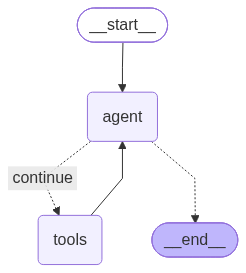

In [30]:
from IPython.display import Image, display

# This visualization shows the flow: Agent → Decision → Tools → Agent → Decision → End
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

<h3>Running the Complete ReAct Agent</h3>
<h4>Final Execution</h4>

<h6>What You'll See:</h6>

- Initial Reasoning: Agent analyzes the query.
- Tool Call 1: Searches for Zurich weather.
- Tool Result Processing: Agent examines weather data.
- Tool Call 2: Gets clothing recommendations.
- Final Synthesis: Agent combines all information into a helpful response.

In [31]:
def print_stream(stream):
    """Helper function for formatting the stream nicely."""
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

inputs = {"messages": [HumanMessage(content="What's the weather like in Zurich, and what should I wear based on the temperature?")]}

print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

What's the weather like in Zurich, and what should I wear based on the temperature?
================================== Ai Message ==================================
Tool Calls:
  search_tool (bfbfc6ca-9a6a-4618-be4f-ba2a5c49b1d9)
 Call ID: bfbfc6ca-9a6a-4618-be4f-ba2a5c49b1d9
  Args:
    query: weather in Zurich
================================= Tool Message =================================
Name: search_tool

[{"title": "Z\u00fcrich weather table Sep 10, 2026", "url": "https://weather5days.com/en/table/z%C3%BCrich,switzerland/5day", "content": "| 16:00 | Sunny | 20 \u00b0C | 2% | 8% | 49% | 767 mm Hg | SE 127\u00b0 1.69 (5.11) m/s | 6 |\n| 17:00 | Sunny | 21 \u00b0C | 2% | 9% | 48% | 767 mm Hg | NNE 13\u00b0 1.61 (4.61) m/s | 6 |\n| 18:00 | Sunny | 20 \u00b0C | 3% | 8% | 56% | 767 mm Hg | NE 37\u00b0 1.61 (5.19) m/s | 5 |\n| 19:00 | Sunny | 19 \u00b0C | 4% | 6% | 64% | 768 mm Hg | ENE 62\u00b0 1.5 (5.89)

<h2>The Complete ReAct Cycle</h2>
The final execution demonstrates the full ReAct pattern:

- Reasoning: "I need current weather data for Zurich".
- Acting: Calls search_tool("Zurich weather today").
- Observing: Processes search results, extracts temperature.
- Reasoning: "Now I need clothing recommendations for this temperature".
- Acting: Calls recommend_clothing("temperature from search").
- Observing: Gets clothing suggestions.
- Reasoning: "I can now provide a complete answer".
- Final Response: Synthesizes weather info and clothing recommendations.

<h2>Key Takeaways</h2>
<h3>What Makes ReAct Powerful</h3>
- Transparency: You can see the agent's reasoning process.
- Adaptability: The agent can handle unexpected results and change course.
- Extensibility: It's easy to add new tools and capabilities.
- Reliability: The structured approach reduces hallucination and improves accuracy

<h3>Best Practices</h3>
- Tool Design: Make tools focused and reliable.
- Error Handling: Plan for tool failures and unexpected results.
- Context Management: Keep state manageable and relevant.
- User Experience: Provide clear feedback about what the agent is doing.

The ReAct framework represents a significant step toward more capable and trustworthy AI agents that can reason through complex problems and take meaningful actions in the real world.

Exercise 1 - Build a Calculator Tool
<p>
Objective: Create a mathematical calculator tool that can handle complex calculations.
<p>
Your task is to create a calculator tool that can perform mathematical operations. This tool should be able to handle expressions like "2 + 3 * 4", "sqrt(16)", and "sin(π/2)".
<p>
Instructions:

- Create a tool called calculator_tool using the @tool decorator.
- The tool should accept a mathematical expression as a string.
- Use Python's eval() function carefully (or better yet, use the ast module for safety).
- Test your tool with various mathematical expressions.
- Add your tool to the tools list and test it with the ReAct agent.


In [35]:
import math
import ast
import operator

@tool
def calculator_tool(expression: str) -> str:
    """
    Safely evaluate mathematical expressions.
    
    :param expression: A mathematical expression as a string (e.g., "2 + 3 * 4")
    :return: The result of the calculation
    """
    # TODO: Implement safe mathematical evaluation
    # Hint: You can use ast.literal_eval for simple expressions
    result = ast.literal_eval(expression)
    # or create a safe evaluator for more complex math
    return str(result)

# TODO: Add calculator_tool to your tools list
tools = [calculator_tool]

# TODO: Test with the agent: "What's 15% of 250 plus the square root of 144?"
model_react.invoke({"scratch_pad": [HumanMessage(content="What's 15% of 250 plus the square root of 144?")]})

AIMessage(content='This is a multi-step math problem. I will solve it by breaking it down into parts.\n\n### Step 1: Calculate 15% of 250\nTo find 15% of 250, you can convert the percentage to a decimal ($15\\% = 0.15$) and multiply:\n$$0.15 \\times 250 = 37.5$$\n\n*(Alternatively, $10\\%$ of $250$ is $25$, and $5\\%$ of $250$ is half of $25$, which is $12.5$. So, $25 + 12.5 = 37.5$.)*\n\n### Step 2: Calculate the square root of 144\nThe square root of 144 is the number that, when multiplied by itself, equals 144:\n$$\\sqrt{144} = 12$$\n\n### Step 3: Add the results\nFinally, I add the result from Step 1 and the result from Step 2:\n$$37.5 + 12 = 49.5$$\n\n***\n\n**Answer:** 15% of 250 plus the square root of 144 is **49.5**.', additional_kwargs={}, response_metadata={'model': 'gemma4', 'created_at': '2026-09-10T13:16:20.7715239Z', 'done': True, 'done_reason': 'stop', 'total_duration': 14420514600, 'load_duration': 5410600, 'prompt_eval_count': 340, 'prompt_eval_duration': 678032000, '

Exercise 2 - Create a News Summary Tool
<p>
Objective: Build a tool that can fetch and summarize recent news articles.
<p>
Create a news summarization tool that works with the existing search functionality. This tool should take search results and create concise summaries of news articles.
<p>
Instructions:

- Create a news_summarizer_tool that takes news content and creates summaries.
- The tool should extract key information: headline, date, main points.
- Format the output in a readable way.
- Test it by asking the agent to "search for recent AI news and summarize the top 3 articles".

In [40]:
@tool
def news_summarizer_tool(news_content: str) -> str:
    """
    Summarize news articles from search results.
    
    :param news_content: Raw news content or search results
    :return: A formatted summary of the news
    """
    # TODO: Parse the news content
    # TODO: Extract key information (headlines, dates, main points)
    # TODO: Format into a readable summary
    # Hint: You might want to split by articles and process each one
    return news_content  + "TODO summarization" # Placeholder return; implement actual summarization logic here

# TODO: Add to tools list and test with:
tools = [search_tool, news_summarizer_tool]
tools_by_name = {tool.name: tool for tool in tools}

# "Find recent news about artificial intelligence and give me a summary"
llm_with_tools = llm.bind_tools(tools)
model_react=chat_prompt| llm_with_tools
model_react.invoke({"scratch_pad": [HumanMessage(content="Find recent news about artificial intelligence and give me a summary")]})

AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gemma4', 'created_at': '2026-09-10T16:01:45.763852Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3336973700, 'load_duration': 8414200, 'prompt_eval_count': 248, 'prompt_eval_duration': 632535000, 'eval_count': 131, 'eval_duration': 2625733000, 'logprobs': None, 'model_name': 'gemma4'}, id='run--01a08c0d-b019-7713-9880-cf59a1a987a7-0', tool_calls=[{'name': 'search_tool', 'args': {'query': 'recent news about artificial intelligence'}, 'id': '22f51b0c-9248-4f67-9b01-880b8c55fffd', 'type': 'tool_call'}], usage_metadata={'input_tokens': 248, 'output_tokens': 131, 'total_tokens': 379})

In [36]:
# Exercise 1 Test
inputs = {"messages": [HumanMessage(content="Calculate 15% of 250 plus the square root of 144")]}
print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Calculate 15% of 250 plus the square root of 144
================================== Ai Message ==================================

This is a straightforward calculation. I will break it down into three steps:

### Step 1: Calculate 15% of 250
To find the percentage, convert $15\%$ to a decimal ($0.15$) and multiply it by $250$:
$$0.15 \times 250 = 37.5$$

### Step 2: Calculate the square root of 144
The square root of 144 is the number that, when multiplied by itself, equals 144.
$$\sqrt{144} = 12$$ (Since $12 \times 12 = 144$)

### Step 3: Add the results
Now, add the result from Step 1 and the result from Step 2:
$$37.5 + 12 = 49.5$$

**Answer:**
$15\%$ of $250$ plus the square root of $144$ equals **49.5**.


In [41]:
# Exercise 2 Test  
inputs = {"messages": [HumanMessage(content="Find recent AI news and summarize the top 3 articles")]}
print_stream(graph.stream(inputs, stream_mode="values"))    

================================ Human Message =================================

Find recent AI news and summarize the top 3 articles
================================== Ai Message ==================================
Tool Calls:
  search_tool (d5dead70-5d25-4c52-b922-4ce6d9452020)
 Call ID: d5dead70-5d25-4c52-b922-4ce6d9452020
  Args:
    query: recent AI news
================================= Tool Message =================================
Name: search_tool

[{"title": "Artificial Intelligence - Latest AI News and Analysis", "url": "https://www.wsj.com/tech/ai", "content": "The Hidden Debt That Apple Owes to the CIA\n\n### The Hidden Debt That Apple Owes to the CIA\n\nWhy Big Tech\u2019s AI Spending Is $3 Trillion Higher Than It Seems\n\n### Why Big Tech\u2019s AI Spending Is $3 Trillion Higher Than It Seems\n\n## Related Opinion\n\nView All\n\nSenator Elizabeth Warren, a Democrat from Massachusetts, during a Senate Banking, Housing, and Urban Affairs Committee hearing in Washington, DC